# Pre-screening

## Documents exploration

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os
from importlib import reload

from matereview import io
reload(io)

print(f"Current working directory: {os.getcwd()}")

Current working directory: D:\projects\MateReview\notebooks


In [14]:
# Load the data
# filepath = Path("../data/REV1-SCOPUS-9/FullExport.csv")
filepath = Path("../data/scopus_query_20260408_152613.csv")
metadata_df = io.read_csv(filepath)
metadata_df.head()

,eid,DOI,pii,pubmed_id,Title,subtype,Document Type,creator,afid,affilname,...,Abstract,authkeywords,citedby_count,openaccess,freetoread,freetoreadLabel,fund_acr,fund_no,fund_sponsor,Year
0,2-s2.0-105033489425,10.1038/s41598-026-41773-z,NaN,41741621.0,A physics-informed hybrid ML framework for por...,ar,Article,Tahvildari S.P.,60022927;60027666;60105242,University of Tehran;Sharif University of Tech...,...,Accurate prediction of formation pore pressure...,Adaptive calibration | Carbonate reservoirs | ...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,NaN,NaN,NaN,2026
1,2-s2.0-105033433119,10.1038/s41467-026-69170-0,NaN,41826298.0,Impact of solvent forces and broken symmetry o...,ar,Article,Yadav Schmid S.,60015481;60021199;60028548;60028186;60007174;6...,University of Washington;Consiglio Nazionale d...,...,The era of protein design has enabled the crea...,NaN,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,ORNL,DE-SC0018940,Indian Institute of Science Education and Rese...,2026
2,2-s2.0-105031841732,10.1038/s41612-026-01334-7,NaN,NaN,Bridging idealized and operational models: an ...,ar,Article,Behnoudfar P.,60032179;60116488,University of Wisconsin-Madison;Institut Polyt...,...,Computer models are indispensable tools for un...,NaN,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,ONRST,N00014-24-1-2244,Office of Naval Research,2026
3,2-s2.0-105031839203,10.1038/s41598-026-39466-8,NaN,41667775.0,Integrating deep learning with physics based m...,ar,Article,Kodchakorn K.,60000881;60032250,"Chiang Mai University;Faculty of Medicine, Chi...",...,Accurate antibody-antigen (Ab-Ag) docking is h...,Deep learning | DockQ | Molecular docking | Pa...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,NRCT,N34E670096,National Research Council of Thailand,2026
4,2-s2.0-105031688150,10.1038/s41598-025-32041-7,NaN,41771965.0,An integrated physics-guided machine learning ...,ar,Article,Elahi M.,60000937;60068730;60005762;60104814;60006822,Shenzhen University;OsloMet – StorbyUniversite...,...,Accurate prediction of fracture energy (G<inf>...,Asphalt mixtures | Fracture energy | Physics-g...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,SOE,NaN,Soproni Egyetem,2026


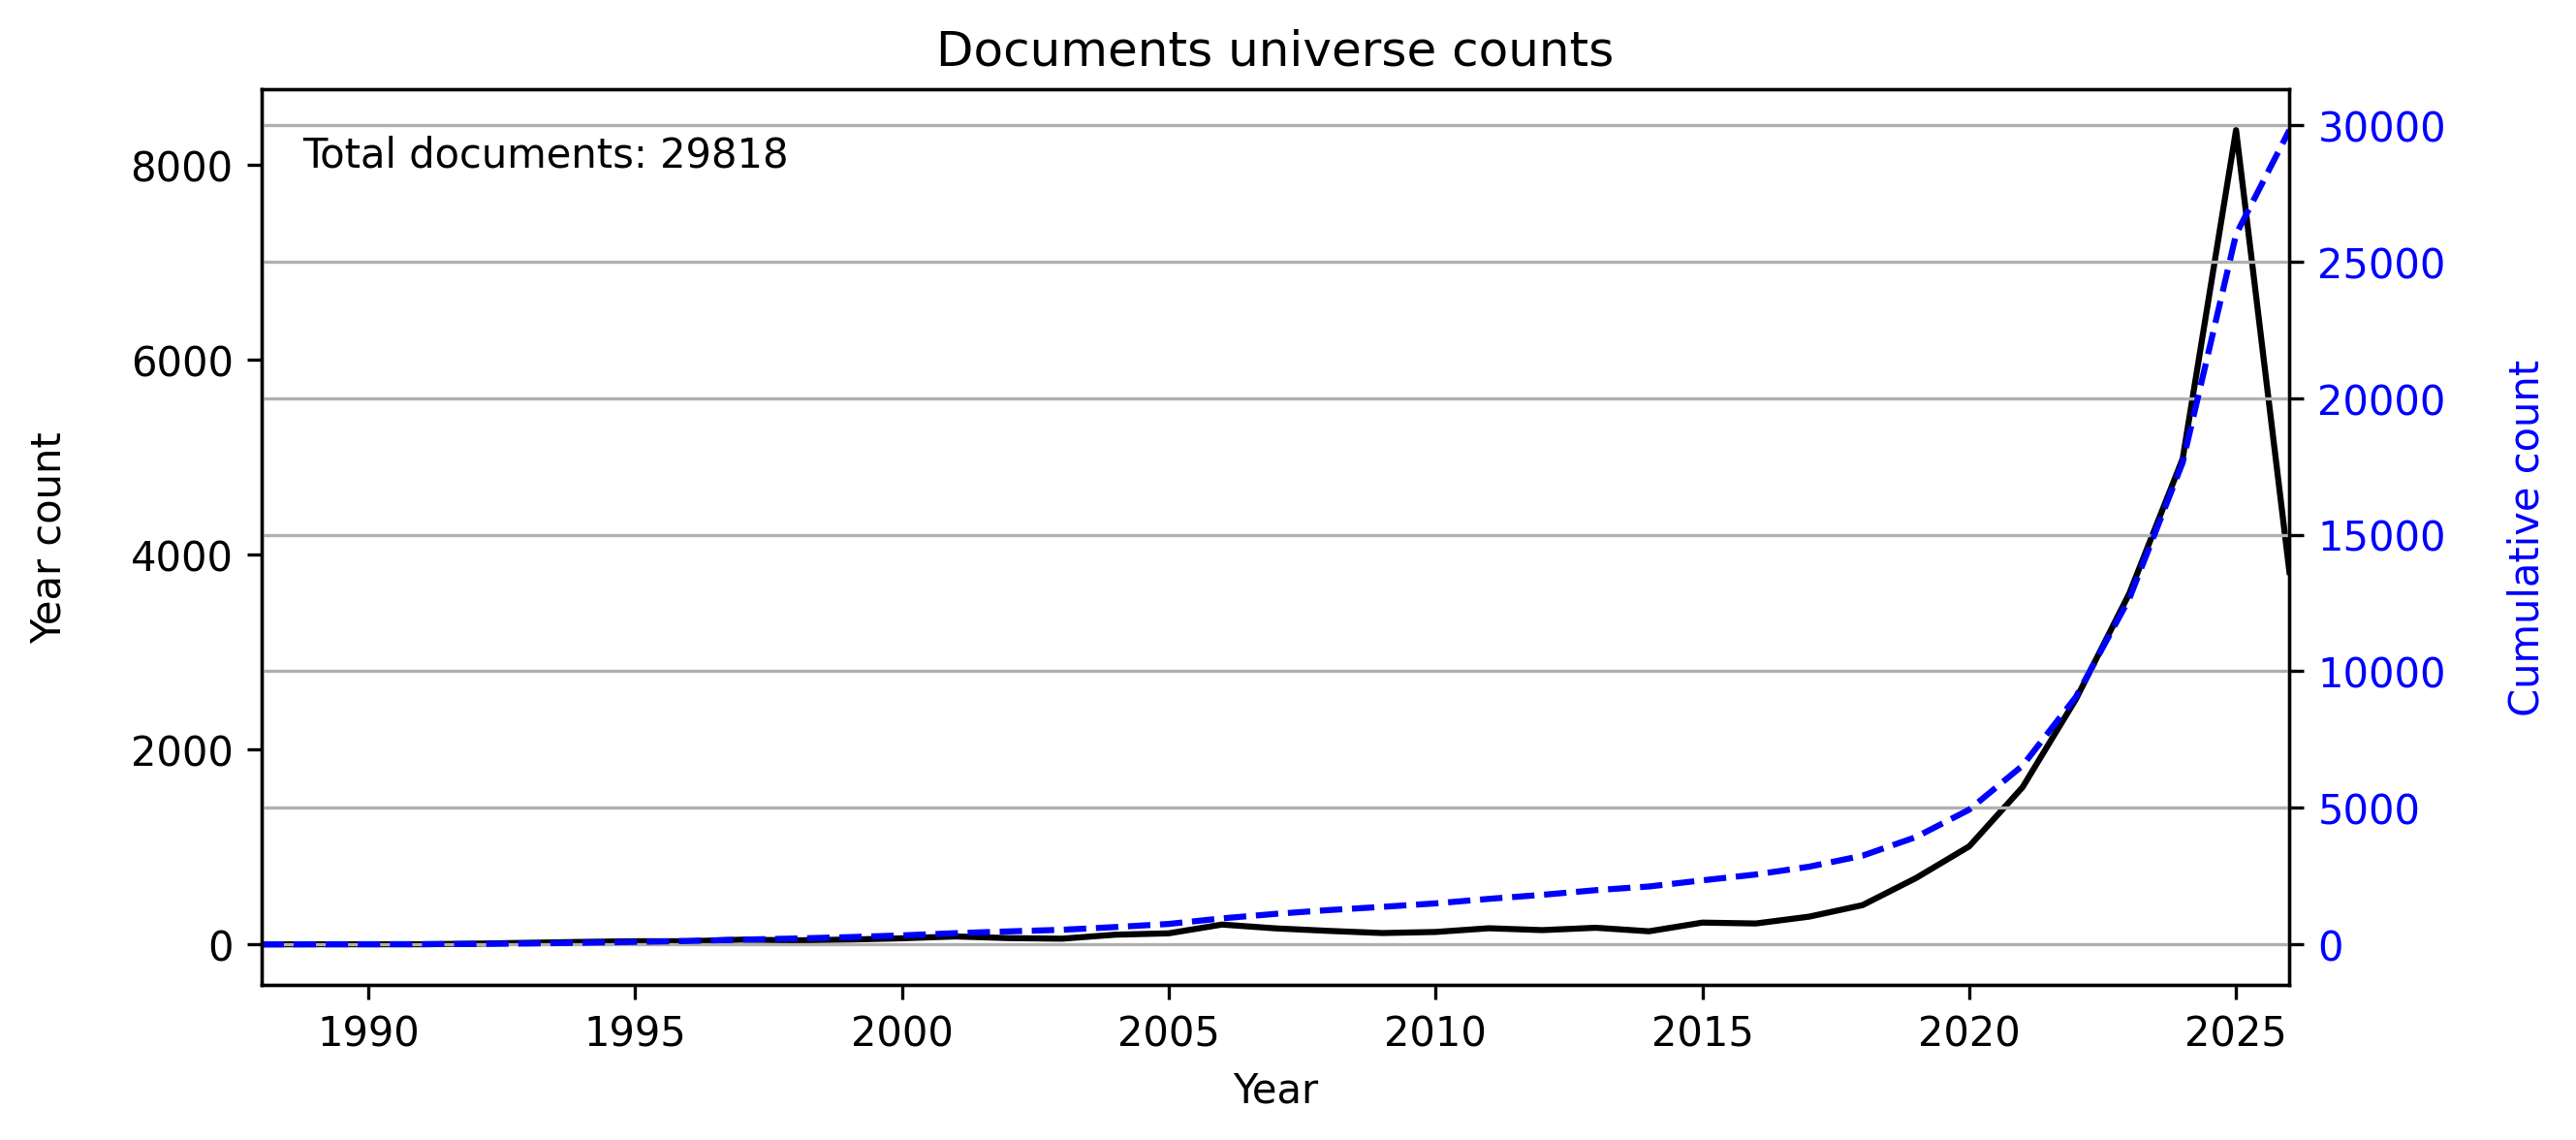

In [8]:
# PLot counts per year
fig, ax = plt.subplots(dpi=300, figsize=(9,4))
metadata_df["Year"].value_counts().sort_index().plot(color="black")
ax.set_ylabel("Year count", labelpad=15)

# Accumulated on right axis
ax2 = ax.twinx()
metadata_df["Year"].value_counts().sort_index().cumsum().plot(color="blue", ax=ax2, linestyle="--")
ax2.set_ylabel("Cumulative count", color="blue")
ax2.tick_params(axis='y', labelcolor="blue")
ax2.set_ylabel("Cumulative count", labelpad=15, color="blue")

# Annotate total documents at the top left
total_docs = len(metadata_df)
ax.text(0.02, 0.95, f"Total documents: {total_docs}", transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.title("Documents universe counts")
plt.xlabel("Year")
plt.xlim(1988, 2026)
plt.grid()

## Document filtering and trends

In [9]:
def filter_documents(df, keywords=None, year_range=None, doc_types=None):
    """
    Filters a Scopus metadata DataFrame based on keywords, years, and types.
    """
    filtered_df = df.copy()

    # 1. Filter by Year Range (e.g., (2015, 2024))
    if year_range:
        start_year, end_year = year_range
        filtered_df = filtered_df[
            (filtered_df['Year'].astype(int) >= start_year) &
            (filtered_df['Year'].astype(int) <= end_year)
        ]

    # 2. Filter by Document Type (e.g., ['Article', 'Review'])
    if doc_types:
        filtered_df = filtered_df[filtered_df['Document Type'].isin(doc_types)]

    # 3. Filter by Keywords (Searching Title and Abstract)
    if keywords:
        # Create a combined regex pattern for all keywords
        pattern = '|'.join(keywords)
        # Ensure we check both Title and Abstract, handling NaNs
        mask = (
            filtered_df['Title'].str.contains(pattern, case=False, na=False) |
            filtered_df['Abstract'].str.contains(pattern, case=False, na=False)
        )
        filtered_df = filtered_df[mask]

    return filtered_df

In [10]:
# Define your research topics and their associated keywords
research_topics = {
    "Safety": ["safety", "hazard", "risk"],
    "Reliability": ["reliability", "failure rate", "probabilistic"],
    "Maintenance": ["maintenance", "prognostics", "RUL", "health monitoring"]
}

# 1. Track trends and collect all unique document indices for aggregation
trends = {}
all_filtered_indices = set()

for area, kws in research_topics.items():
    area_df = filter_documents(metadata_df, keywords=kws, doc_types=["Article", "Review"])

    # Store for trends
    # Rename column to include keywords for the legend: "Name: [k1, k2...]"
    label = f"{area}: {kws}"
    trends[label] = area_df.groupby('Year').size()

    # Track indices for total unique count
    all_filtered_indices.update(area_df.index)

# 2. Convert to DataFrame for plotting
trend_df = pd.DataFrame(trends).fillna(0)

# Print total count
print(f"Total unique documents across all topics: {len(all_filtered_indices)}")

Total unique documents across all topics: 4717


Total unique documents aggregated: 4717


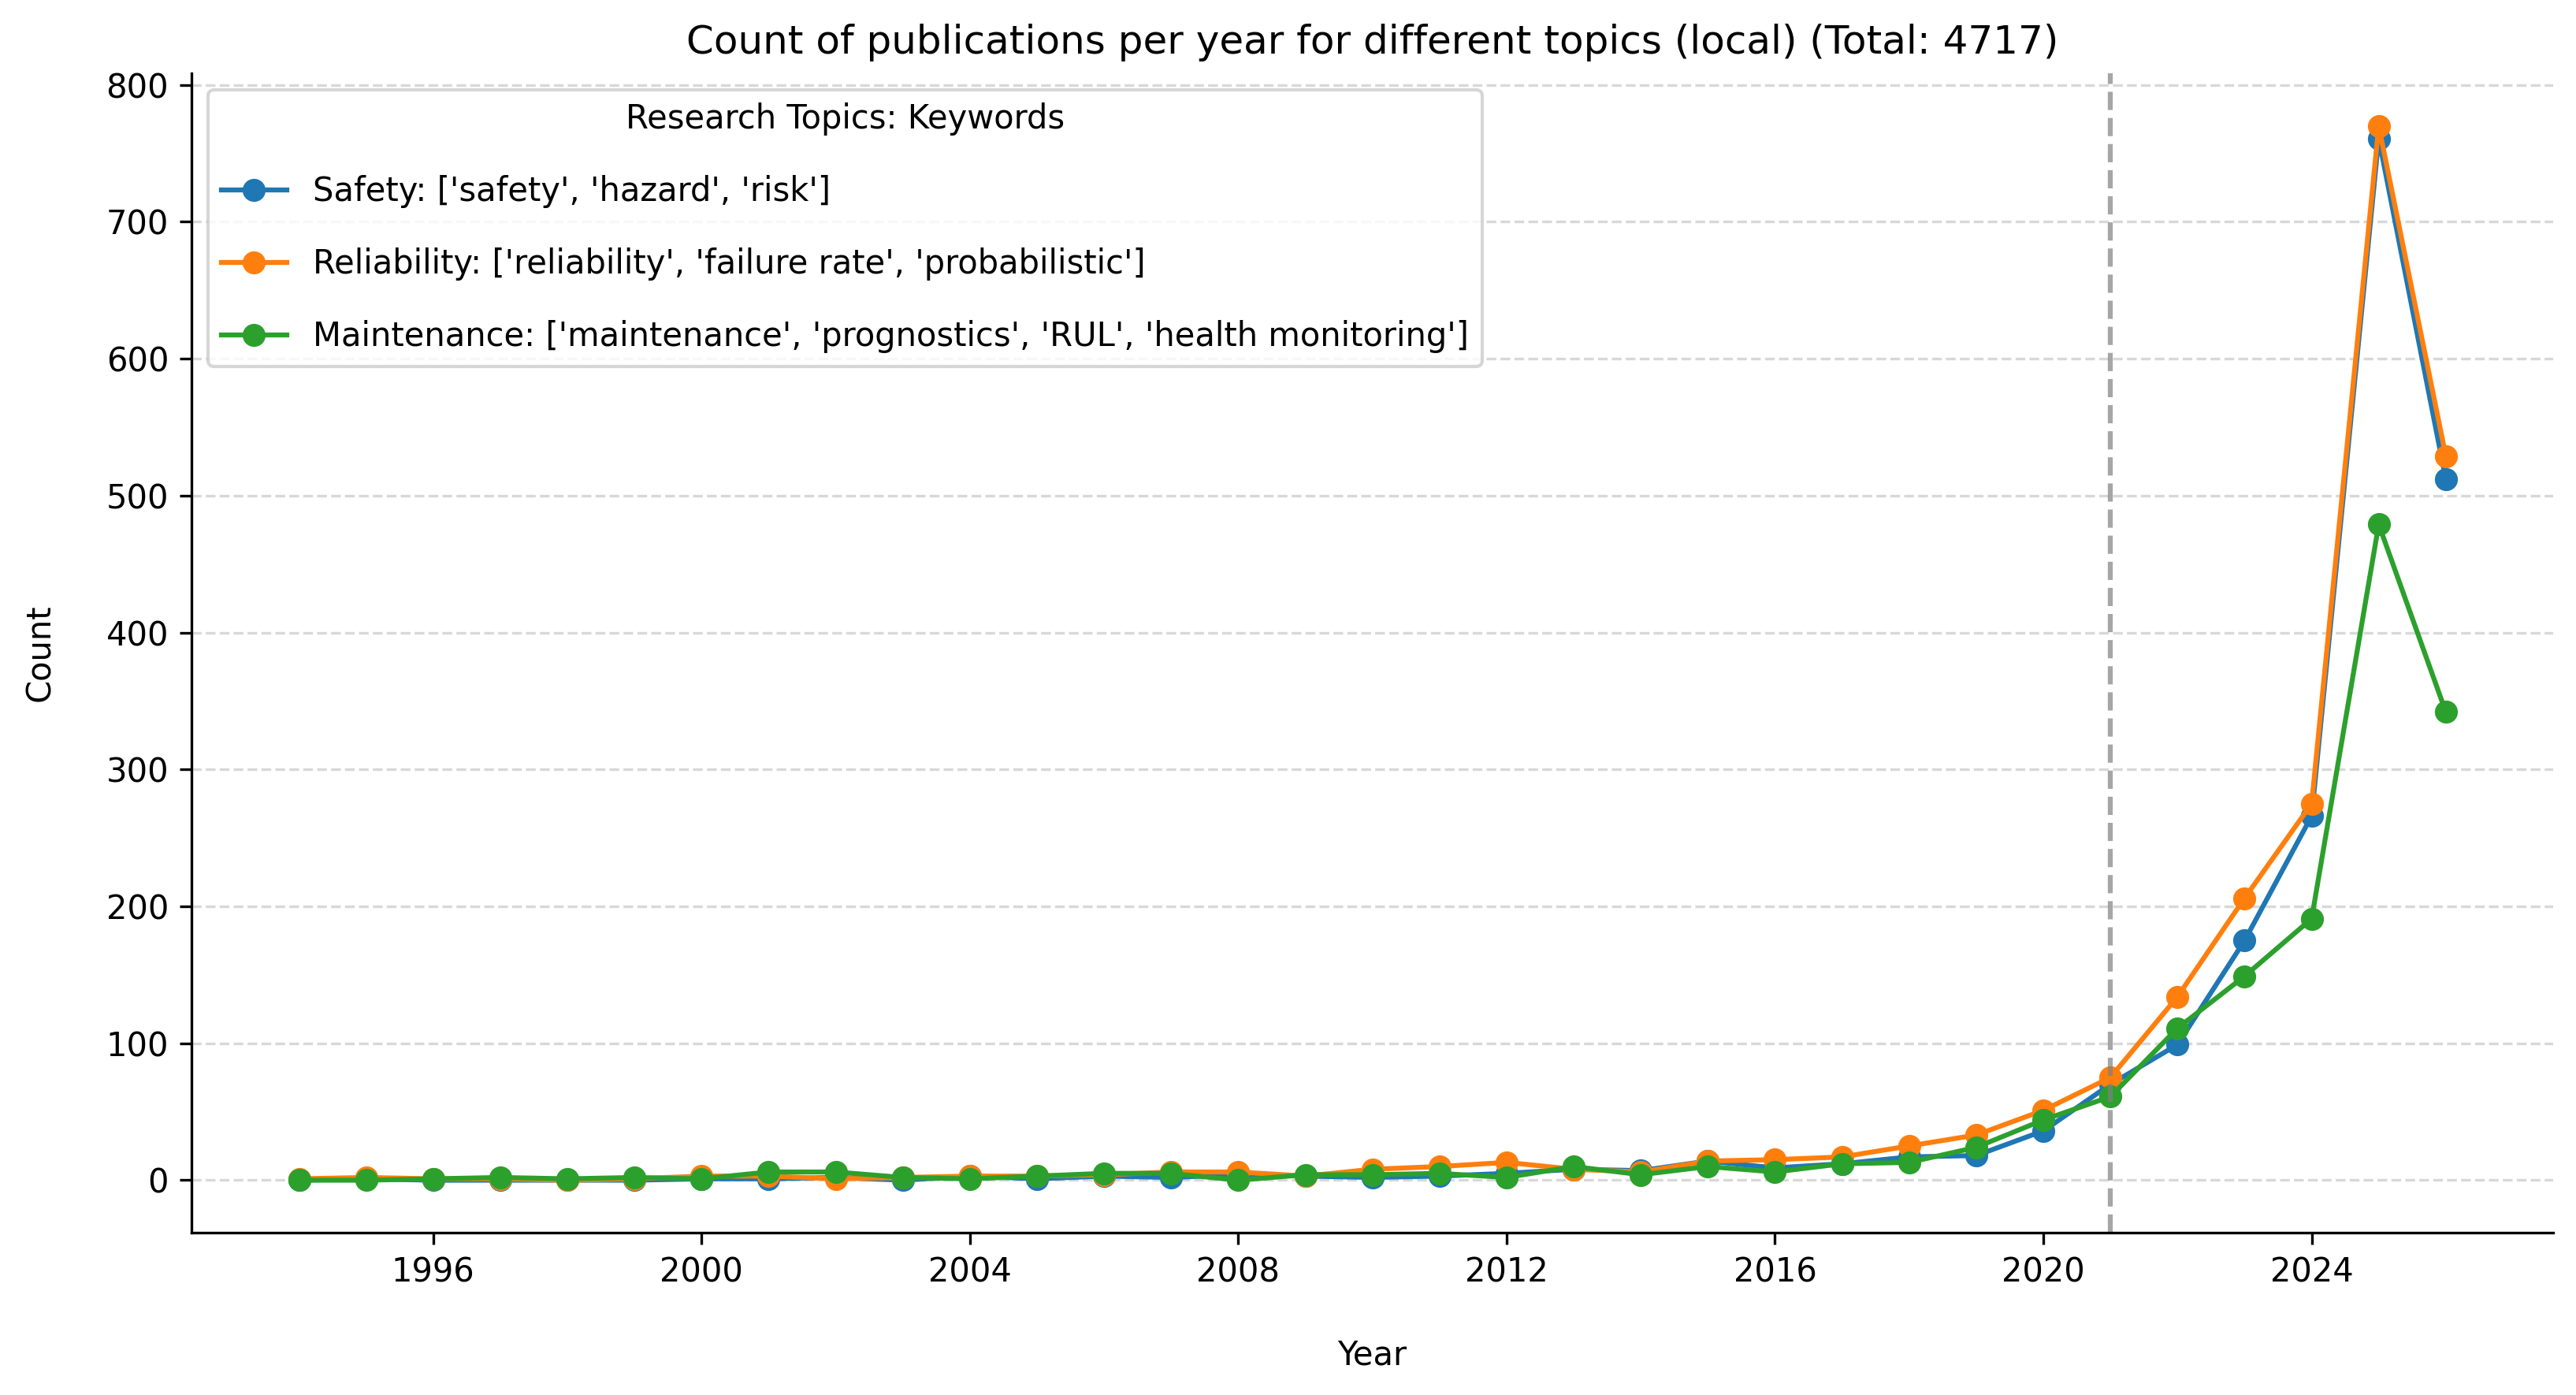

In [11]:
# 4. Styling: Modern, Minimalistic, serif (LaTeX-like)
plt.rcdefaults()


# Professional color palette
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

for i, column in enumerate(trend_df.columns):
    ax.plot(trend_df.index, trend_df[column], label=column, marker='o')

# Vertical line at 2016
ax.axvline(x=2021, color='grey', linestyle='--', alpha=0.7)

# Minimalist axis and grid adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.3)

ax.set_title(f"Count of publications per year for different topics (local) (Total: {len(all_filtered_indices)})")
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("Count", labelpad=15)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Formatting the legend with set names and keywords
ax.legend(title=f"Research Topics: Keywords", loc='upper left', labelspacing=1.2)

plt.tight_layout()
print(f"Total unique documents aggregated: {len(all_filtered_indices)}")

In [30]:
# Get from start_year onward
start_year = 2021
all_kwds = [kw for kws in research_topics.values() for kw in kws]
filtered_start_year = filter_documents(
    metadata_df,
    keywords=all_kwds,
    year_range=(start_year, 2026),
    doc_types=["Article", "Review"]
)

print(f"Number of papers from {start_year}: {len(filtered_start_year)}")
print(f"   - keywords: {all_kwds}")

Number of papers from 2021: 4224
   - keywords: ['safety', 'hazard', 'risk', 'reliability', 'failure rate', 'probabilistic', 'maintenance', 'prognostics', 'RUL', 'health monitoring']


In [20]:
# Extract randomly some samples from the filtered data and print information
sample_size = 5
sample_df = filtered_start_year.sample(sample_size)
for idx, row in sample_df.iterrows():
    print(f"Title: {row['Title']}")
    print(f"  Year: {row['Year']}")
    # print(f"  Source: {row['Source title']}")
    # print(f"  DOI: {row['DOI']}")
    #print(f"Abstract: {row['Abstract']}...")  # Print first 200 characters of the abstract
    print("-" * 80)

Title: CFAST simulations and application of a machine learning algorithm for the fire safety of a switchgear room
  Year: 2026
--------------------------------------------------------------------------------
Title: Accelerating Thermal Response: Physics-Informed Neural Networks for Enhanced Non-invasive Sensing in Low-Conductivity Pipes
  Year: 2026
--------------------------------------------------------------------------------
Title: Ice water path retrievals from Meteosat-9 using quantile regression neural networks
  Year: 2022
--------------------------------------------------------------------------------
Title: Constraining Gaussian processes for physics-informed acoustic emission mapping
  Year: 2023
--------------------------------------------------------------------------------
Title: Digital Twins as Predictive Models for Real-Time Probabilistic Risk Assessment of Autonomous Vehicles
  Year: 2025
--------------------------------------------------------------------------------

In [28]:
# save the filtered data to a new CSV file
filtered_start_year_output_path = Path(f"../data/{filepath.stem}_FilteredPapers.csv")
filtered_start_year.to_csv(filtered_start_year_output_path, index=False)
print(f"Filtered data saved to: {filtered_start_year_output_path}")

Filtered data saved to: ..\data\scopus_query_20260408_152613_FilteredPapers.csv


Number of papers after filtering: 251


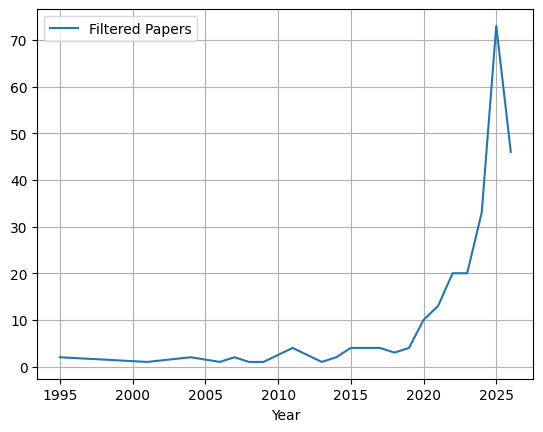

In [25]:
# Filter by keywords in the specified columns
keywords = ["safety", "risk", "reliablity"]
filtered_df = metadata_df[metadata_df["Title"].str.contains("|".join(keywords), case=False, na=False)]
print(f"Number of papers after filtering: {len(filtered_df)}")

# Plot counts per year for the filtered data on top of the original data
fig, ax = plt.subplots()
# metadata_df["Year"].value_counts().sort_index().plot(label="All Papers", ax=ax)
filtered_df["Year"].value_counts().sort_index().plot(label="Filtered Papers", ax=ax)
plt.legend()
plt.grid()

## Final adjustments

In [17]:
import pybliometrics
pybliometrics.scopus.init()

In [22]:
# Manually include the baseline references and their citations
references_doi = [
    "10.1016/j.compchemeng.2022.107898",
    "10.1016/j.eswa.2024.124678"
]

# Query metadata of the references from Scopus
results = []
for doi in references_doi:
    query = f'DOI("{doi}")'
    try:
        result = pybliometrics.scopus.ScopusSearch(query)
        result_df = pd.DataFrame(result.results)
        results.append(result_df)
        print(f"Retrieved metadata for DOI: {doi}")
    except Exception as e:
        print(f"Error retrieving metadata for DOI {doi}: {e}")

refs_df = pd.concat(results, ignore_index=True)
refs_df = io.column_cleaning(refs_df)

Retrieved metadata for DOI: 10.1016/j.compchemeng.2022.107898
Retrieved metadata for DOI: 10.1016/j.eswa.2024.124678


In [23]:
refs_dois_df = io.read_csv('../data/baselines/ref_doi.csv')

In [24]:
# Put everything together
combined_df = pd.concat([filtered_start_year, refs_df, refs_dois_df], ignore_index=True)

C:\Users\Juan-Pablo Futalef\AppData\Local\Temp\ipykernel_131492\3826590841.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([filtered_start_year, refs_df, refs_dois_df], ignore_index=True)


In [31]:
# Remove duplicates based on DOI (if available) or Title as a fallback
combined_df.drop_duplicates(subset='DOI', inplace=True)
combined_df.drop_duplicates(subset='Title', inplace=True)

In [32]:
len(combined_df)

4457

In [33]:
# Save the combined data to a new CSV file
combined_df_filepath = Path(f"../data/{filepath.stem}_ToASReview.csv")
combined_df.to_csv(combined_df_filepath, index=False)
print(f"Saved to: {combined_df_filepath}")

Saved to: ..\data\scopus_query_20260408_152613_ToASReview.csv
